Different papers analyse what is the best sampling ratio for different tasks. 1:5 to 1:15 is recommended. I will use 1:10.

Also, for scanning new information, newer papers are more relevant, hence in the sampling I will put more emphasis on recent papers.

Here I am looking for a funciton I am happy with to assign weights for the sampling:

# Making the samples

## Choosing a distribution

In [6]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import os


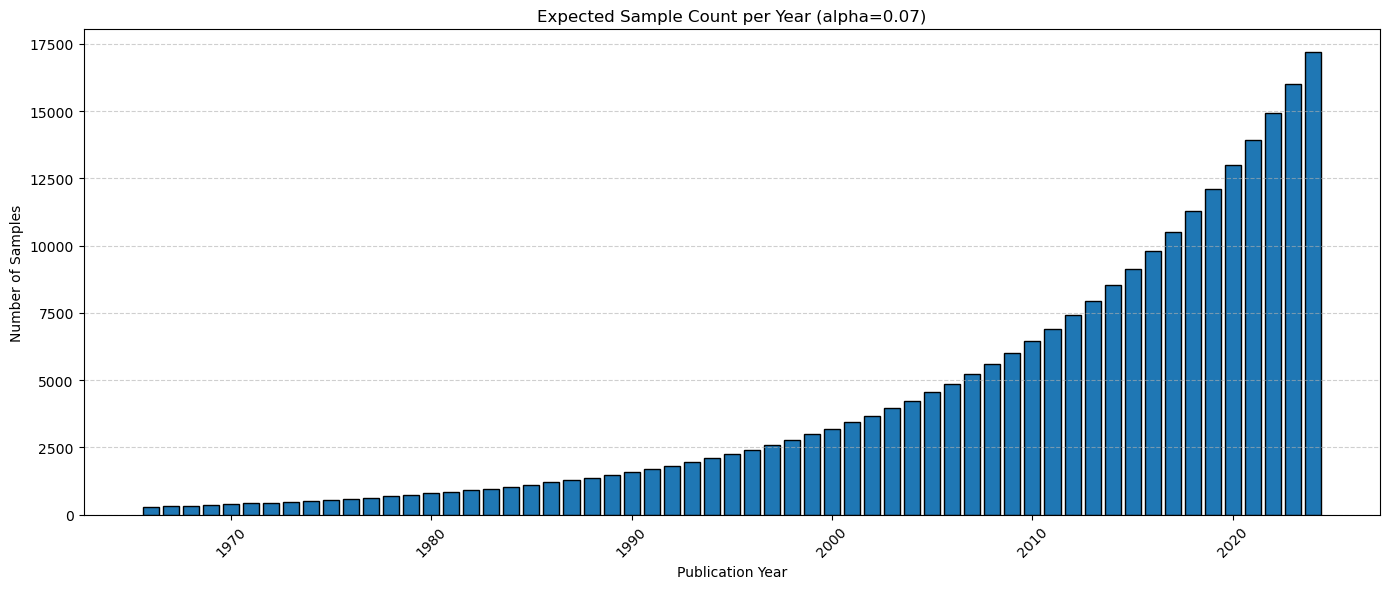

Samples from 2005–2024: 191420 (76.6%)


In [ ]:

# Settings
start_year = 1966
end_year = 2024
target_sample_size = 250_000
alpha = 0.07  # try 0.06 - 0.1 for tuning

# Generate year range and weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()  # Normalize
expected_samples = (weights * target_sample_size).astype(int)

# Plot
plt.figure(figsize=(14, 6))
plt.bar(years, expected_samples, edgecolor='black')
plt.title(f"Expected Sample Count per Year (alpha={alpha})")
plt.xlabel("Publication Year")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

# Optional: print percentage of samples from 2005+
post_2005_total = expected_samples[years >= 2005].sum()
print(f"Samples from 2005–2024: {post_2005_total} ({post_2005_total / target_sample_size:.1%})")

## 250k with abstracts

In [10]:
# SETTINGS
filename = 'H:/Datasets/pubmed_full.csv'
output_path = 'Samples/pubmed_sample_250k.csv'
chunksize = 1_000_000
target_sample_size = 250_000
start_year, end_year = 1966, 2024
alpha = 0.07
total_rows_estimate = 38_000_000

# Columns to use
df_preview = pd.read_csv(filename, nrows=5)
use_columns = df_preview.columns.tolist()

year_column = 'year'
abstract_column = 'abstract'

# STEP 1: Compute exponential weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()
expected_counts = (weights * target_sample_size).astype(int)
year_to_sample_count = dict(zip(years, expected_counts))

# STEP 2: Sampling loop
samples = []
total_collected = defaultdict(int)

with pd.read_csv(filename, chunksize=chunksize, usecols=use_columns, dtype={year_column: str}) as reader:
    with tqdm(total=total_rows_estimate, desc="Sampling PubMed", unit="rows") as pbar:
        for chunk in reader:
            pbar.update(len(chunk))

            # Clean and filter
            chunk[year_column] = pd.to_numeric(chunk[year_column], errors='coerce').astype('Int64')
            chunk = chunk.dropna(subset=[year_column, abstract_column])  # Drop rows missing year or abstract

            for year in years:
                year_chunk = chunk[chunk[year_column] == year]
                remaining = year_to_sample_count[year] - total_collected[year]
                if remaining > 0:
                    take_n = min(remaining, len(year_chunk))
                    if take_n > 0:
                        sampled = year_chunk.sample(n=take_n, random_state=42)
                        samples.append(sampled)
                        total_collected[year] += take_n

            if sum(total_collected.values()) >= target_sample_size:
                break

# STEP 3: Combine and Save
sampled_df = pd.concat(samples).reset_index(drop=True)
sampled_df.to_csv(output_path, index=False)

print(f" Sample saved: {output_path}")
print(f" Final sample size: {len(sampled_df)} rows (no null abstracts)")


Sampling PubMed:  13%|█▎        | 5000000/38000000 [01:08<07:06, 77297.74rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  32%|███▏      | 12000000/38000000 [02:52<07:02, 61504.29rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  34%|███▍      | 13000000/38000000 [03:06<06:33, 63496.01rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\3398523281.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed:  96%|█████████▌| 36570000/38000000 [10:25<00:24, 58506.07rows/s]


 Sample saved: Samples/pubmed_sample_250k.csv
 Final sample size: 249971 rows (no null abstracts)


## 400k no abstracts

In [14]:
# SETTINGS
filename = 'H:/Datasets/pubmed_full.csv'
output_path = 'Samples/pubmed_sample_titles_400k.csv'
chunksize = 1_000_000
target_sample_size = 400_000
start_year, end_year = 1966, 2024
alpha = 0.07
total_rows_estimate = 38_000_000

# STEP 1: Read all columns (except we'll drop abstract *after* sampling)
df_preview = pd.read_csv(filename, nrows=5)
use_columns = df_preview.columns.tolist()

year_column = 'year'
abstract_column = 'abstract'

# STEP 2: Compute sampling weights
years = np.arange(start_year, end_year + 1)
weights = np.exp(alpha * (years - start_year))
weights /= weights.sum()
expected_counts = (weights * target_sample_size).astype(int)
year_to_sample_count = dict(zip(years, expected_counts))

# STEP 3: Sample using chunks
samples = []
total_collected = defaultdict(int)

with pd.read_csv(filename, chunksize=chunksize, usecols=use_columns, dtype={year_column: str}) as reader:
    with tqdm(total=total_rows_estimate, desc="Sampling PubMed (Drop Abstract)", unit="rows") as pbar:
        for chunk in reader:
            pbar.update(len(chunk))

            chunk[year_column] = pd.to_numeric(chunk[year_column], errors='coerce').astype('Int64')
            chunk = chunk.dropna(subset=[year_column])  # Keep rows with valid year

            for year in years:
                year_chunk = chunk[chunk[year_column] == year]
                remaining = year_to_sample_count[year] - total_collected[year]
                if remaining > 0:
                    take_n = min(remaining, len(year_chunk))
                    if take_n > 0:
                        sampled = year_chunk.sample(n=take_n, random_state=42)
                        samples.append(sampled)
                        total_collected[year] += take_n

            if sum(total_collected.values()) >= target_sample_size:
                break

# STEP 4: Combine, drop abstract, and save
sampled_df = pd.concat(samples).reset_index(drop=True)

if abstract_column in sampled_df.columns:
    sampled_df.drop(columns=[abstract_column], inplace=True)

sampled_df.to_csv(output_path, index=False)

print(f"Sample saved: {output_path}")
print(f"Final sample size: {len(sampled_df)} rows (excluding abstract column)")

Sampling PubMed (Drop Abstract):  13%|█▎        | 5000000/38000000 [01:06<06:51, 80125.47rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  32%|███▏      | 12000000/38000000 [03:01<06:45, 64130.76rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  34%|███▍      | 13000000/38000000 [03:03<06:30, 64082.35rows/s]C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\4269387589.py:30: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in reader:
Sampling PubMed (Drop Abstract):  96%|█████████▌| 36570000/38000000 [10:13<00:23, 59645.8

Sample saved: Samples/pubmed_sample_titles_400k.csv
Final sample size: 399972 rows (excluding abstract column)


# Joining the data

## Loading in the datasets

In [18]:
df_ntds = pd.read_csv('Datasets/publicationsDatasetInfoPortals.csv')
df_250k = pd.read_csv('Samples/pubmed_sample_250k.csv')
df_400k = pd.read_csv('Samples/pubmed_sample_titles_400k.csv')

In [24]:
df_ntds_no_nan_abstract = df_ntds[df_ntds['bibcite_abst_e__value'].notna()].copy()
df_ntds_no_nan_abstract.shape

(25435, 29)

In [29]:
df_match_title = pd.read_csv('Aggregates/title_exact_norm_matches_dedup.csv')
print(df_match_title.shape)
print(df_match_title.columns)
df_match_doi = pd.read_csv('Aggregates/doi_matches.csv')
print(df_match_doi.shape)
print(df_match_doi.columns)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\1856057132.py:1: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  df_match_title = pd.read_csv('Aggregates/title_exact_norm_matches_dedup.csv')


(30968, 43)
Index(['pmid', 'title_large', 'abstract', 'authors', 'language', 'year',
       'month', 'publication_type', 'country', 'agency', 'mesh_terms', 'doi',
       'norm_title_large', 'Unnamed: 0', 'bib_id', 'bibcite_type', 'uuid',
       'bibcite_title', 'bibcite_year', 'bibcite_secondary_title',
       'bibcite_url', 'bibcite_doi', 'bibcite_abst_e__value',
       'bibcite_abst_f__value', 'bibcite_notes__value',
       'bibcite_custom1__value', 'entity_id', 'field_bibcite_target_id', 'nid',
       'vid', 'type', 'langcode', 'title_small',
       'field_domain_access_target_id', 'Type2', 'Type3', 'Type4', 'Type6',
       'Type7', 'Type8', 'Disease', 'Keywords', 'norm_title_small'],
      dtype='object')
(9911, 41)
Index(['pmid', 'title_large', 'abstract', 'authors', 'language', 'year',
       'month', 'publication_type', 'country', 'agency', 'mesh_terms', 'doi',
       'Unnamed: 0', 'bib_id', 'bibcite_type', 'uuid', 'bibcite_title',
       'bibcite_year', 'bibcite_secondary_title

## Removing the papers that are in the infoNTD form the samples
To avoid duped data

In [31]:
# Step 1: Get matched PMIDs
pmids_title_matches = set(df_match_title['pmid'].dropna().astype(str))
pmids_doi_matches = set(df_match_doi['pmid'].dropna().astype(str))

# Step 2: Combine into one exclusion set
pmids_to_remove = pmids_title_matches.union(pmids_doi_matches)

# Step 3: Clean df_250k
print(f"📦 250k sample before cleaning: {df_250k.shape}")
df_250k['pmid'] = df_250k['pmid'].astype(str)
df_250k_clean = df_250k[~df_250k['pmid'].isin(pmids_to_remove)]
removed_250k = len(df_250k) - len(df_250k_clean)
print(f"✅ 250k sample after cleaning: {df_250k_clean.shape} ({removed_250k} removed)")

# Step 4: Clean df_400k
print(f"\n📦 400k sample before cleaning: {df_400k.shape}")
df_400k['pmid'] = df_400k['pmid'].astype(str)
df_400k_clean = df_400k[~df_400k['pmid'].isin(pmids_to_remove)]
removed_400k = len(df_400k) - len(df_400k_clean)
print(f"✅ 400k sample after cleaning: {df_400k_clean.shape} ({removed_400k} removed)")


📦 250k sample before cleaning: (249971, 12)
✅ 250k sample after cleaning: (249869, 12) (102 removed)

📦 400k sample before cleaning: (399972, 11)
✅ 400k sample after cleaning: (399759, 11) (213 removed)


## Joining and making target

In [38]:
# Step 1: Clean and tag NTDs
df_ntds_all = df_ntds.copy()
df_ntds_all['target'] = 1  # Mark as positive class

# Subset for 250k (abstracts only)
df_ntds_with_abstract = df_ntds_all[df_ntds_all['bibcite_abst_e__value'].notna()].copy()

# Step 2: Rename NTD columns to match sample structure for key fields
def rename_ntds_columns(df):
    return df.rename(columns={
        'bibcite_year': 'year',
        'bibcite_doi': 'doi',
        'bibcite_abst_e__value': 'abstract'
    })

df_ntds_250k = rename_ntds_columns(df_ntds_with_abstract)
df_ntds_400k = rename_ntds_columns(df_ntds_all)

# Step 3: Label sample datasets
df_250k_clean['target'] = 0
df_400k_clean['target'] = 0

# Step 4: Combine — outer concat to include all columns from both sides
df_combined_250k = pd.concat([df_250k_clean, df_ntds_250k], ignore_index=True, sort=False)
df_combined_400k = pd.concat([df_400k_clean, df_ntds_400k], ignore_index=True, sort=False)

# Step 5: Report
print(f"📦 Combined 250k shape: {df_combined_250k.shape}")
print(f"✅ 250k — Target=1: {df_combined_250k['target'].sum()}, Target=0: {(df_combined_250k['target'] == 0).sum()}")

print(f"\n📦 Combined 400k shape: {df_combined_400k.shape}")
print(f"✅ 400k — Target=1: {df_combined_400k['target'].sum()}, Target=0: {(df_combined_400k['target'] == 0).sum()}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\70867647.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_250k_clean['target'] = 0
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16892\70867647.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_400k_clean['target'] = 0


📦 Combined 250k shape: (275304, 38)
✅ 250k — Target=1: 25435, Target=0: 249869

📦 Combined 400k shape: (442122, 38)
✅ 400k — Target=1: 42363, Target=0: 399759


In [40]:
# Add a unique integer ID to each row
df_combined_250k['row_id'] = np.arange(len(df_combined_250k))
df_combined_400k['row_id'] = np.arange(len(df_combined_400k))

#  make sure it's the first column
cols_250k = ['row_id'] + [col for col in df_combined_250k.columns if col != 'row_id']
cols_400k = ['row_id'] + [col for col in df_combined_400k.columns if col != 'row_id']

df_combined_250k = df_combined_250k[cols_250k]
df_combined_400k = df_combined_400k[cols_400k]


## Adjusting target according to MESH terms

In [43]:
def flag_mesh_terms(df, mesh_column='mesh_terms', target_column='target', base_target_column='target_no_mesh_adjustment', ntd_terms=None):
    """
    Creates a new 'target' column based on mesh term matching, preserving the original target.
    """
    if ntd_terms is None:
        ntd_terms = []

    ntd_set = {term.strip().lower() for term in ntd_terms}

    # Copy original target
    df = df.copy()
    df[base_target_column] = df[target_column]

    # Update target with mesh term flags
    def update_target(row):
        if row[base_target_column] == 1:
            return 1
        mesh_str = row.get(mesh_column, "")
        if pd.isna(mesh_str):
            return 0
        mesh_list = [m.strip().lower() for m in mesh_str.split(';')]
        return int(any(term in ntd_set for term in mesh_list))

    df[target_column] = df.apply(update_target, axis=1)
    return df


In [61]:
# Define NTD-related MeSH terms
ntd_mesh_terms = [
    "Schistosomiasis",
    "Lymphatic Filariasis",
    "Elephantiasis",
    "Leprosy",
    "Leprosy, Tuberculoid",
    "Leprosy, Lepromatous",
    "Leprosy, Borderline",
    "Leprosy, Paucibacillary",
    "Leprosy, Multibacillary",
    "Soil-Transmitted Helminth Infections",
    "Ascaris lumbricoides",
    "Trichuris trichiura",
    "Hookworm Infections",
    "Leishmaniasis",
    "Leishmaniasis, Cutaneous",
    "Leishmaniasis, Visceral",
    "Onchocerciasis",
    "Trachoma",
    "Chagas Disease",
    "American Trypanosomiasis",
    "Buruli Ulcer",
    "Snake Bites",
    "Snake Venoms",
    "Trypanosomiasis, African",
    "Sleeping Sickness",
    "Yaws",
    "Mycetoma",
    "Eumycetoma",
    "Actinomycetoma",
    "Podoconiosis",
    "Dracunculiasis",
    "Guinea Worm Disease",
    "Scabies",
    "Zika Virus Infection",
    "Chromoblastomycosis",
    "Noma"
]

# Apply to both datasets
df_combined_250k_adjusted = flag_mesh_terms(df_combined_250k, ntd_terms=ntd_mesh_terms)
df_combined_400k_adjusted = flag_mesh_terms(df_combined_400k, ntd_terms=ntd_mesh_terms)

# Show change counts
added_250k = (df_combined_250k_adjusted['target'] == 1).sum() - (df_combined_250k_adjusted['target_no_mesh_adjustment'] == 1).sum()
added_400k = (df_combined_400k_adjusted['target'] == 1).sum() - (df_combined_400k_adjusted['target_no_mesh_adjustment'] == 1).sum()

print(f"🆕 250k: {added_250k} rows flagged by mesh_terms")
print(f"🆕 400k: {added_400k} rows flagged by mesh_terms")


🆕 250k: 473 rows flagged by mesh_terms
🆕 400k: 790 rows flagged by mesh_terms


## Making the split

In [62]:
from sklearn.model_selection import train_test_split
import os

In [63]:
# Helper to split and save
def split_and_save(df, name, label_col='target', test_size=0.2, seed=42):
    df_train, df_test = train_test_split(
        df,
        stratify=df[label_col],
        test_size=test_size,
        random_state=seed
    )

    df_train = df_train.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    train_path = f"Datasets/Train/{name}_train.csv"
    test_path = f"Datasets/Test/{name}_test.csv"

    df_train.to_csv(train_path, index=False)
    df_test.to_csv(test_path, index=False)

    print(f"✅ {name} split:")
    print(f"   Train → {train_path} ({df_train.shape[0]} rows, positives: {df_train[label_col].sum()})")
    print(f"   Test  → {test_path}  ({df_test.shape[0]} rows, positives: {df_test[label_col].sum()})")

# Run for both datasets
split_and_save(df_combined_250k_adjusted, name="250k")
split_and_save(df_combined_400k_adjusted, name="400k_titles")

✅ 250k split:
   Train → Datasets/Train/250k_train.csv (220243 rows, positives: 20726)
   Test  → Datasets/Test/250k_test.csv  (55061 rows, positives: 5182)
✅ 400k_titles split:
   Train → Datasets/Train/400k_titles_train.csv (353697 rows, positives: 34522)
   Test  → Datasets/Test/400k_titles_test.csv  (88425 rows, positives: 8631)


In [65]:
# --- 1. Exclude infontd_org → name: infolep
df_250k_infolep = df_combined_250k_adjusted[df_combined_250k_adjusted['field_domain_access_target_id'] != 'infontd_org'].copy()
df_400k_infolep = df_combined_400k_adjusted[df_combined_400k_adjusted['field_domain_access_target_id'] != 'infontd_org'].copy()

split_and_save(df_250k_infolep, name="250k_infolep")
split_and_save(df_400k_infolep, name="400k_titles_infolep")

# --- 2. Exclude leprosy_information_org → name: infontd
df_250k_infontd = df_combined_250k_adjusted[df_combined_250k_adjusted['field_domain_access_target_id'] != 'leprosy_information_org'].copy()
df_400k_infontd = df_combined_400k_adjusted[df_combined_400k_adjusted['field_domain_access_target_id'] != 'leprosy_information_org'].copy()

split_and_save(df_250k_infontd, name="250k_infontd")
split_and_save(df_400k_infontd, name="400k_titles_infontd")

✅ 250k_infolep split:
   Train → Datasets/Train/250k_infolep_train.csv (214426 rows, positives: 14910)
   Test  → Datasets/Test/250k_infolep_test.csv  (53607 rows, positives: 3727)
✅ 400k_titles_infolep split:
   Train → Datasets/Train/400k_titles_infolep_train.csv (346646 rows, positives: 27471)
   Test  → Datasets/Test/400k_titles_infolep_test.csv  (86662 rows, positives: 6868)
✅ 250k_infontd split:
   Train → Datasets/Train/250k_infontd_train.csv (205712 rows, positives: 6195)
   Test  → Datasets/Test/250k_infontd_test.csv  (51428 rows, positives: 1549)
✅ 400k_titles_infontd split:
   Train → Datasets/Train/400k_titles_infontd_train.csv (326858 rows, positives: 7683)
   Test  → Datasets/Test/400k_titles_infontd_test.csv  (81715 rows, positives: 1921)


# Making the disease training set

Challenge: much less data about each disease

## Checking the contents of ntd dataset

In [12]:
import pandas as pd
from collections import Counter
import ast

In [23]:
df_ntds = pd.read_csv("Datasets/publicationsDatasetInfoPortals.csv")
df_ntds.shape

(42363, 29)

In [20]:
#Convert 'Disease' column to actual lists
df_ntds["Disease"] = df_ntds["Disease"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

#Flatten into single list
all_diseases = [disease for sublist in df_ntds["Disease"] for disease in sublist]

#Count frequency of each disease
disease_counts = Counter(all_diseases)

df_disease_counts = pd.DataFrame.from_dict(disease_counts, orient="index", columns=["count"])
df_disease_counts = df_disease_counts.sort_values(by="count", ascending=False)
df_disease_counts

,count
Leprosy (Hansen disease),32430
Lymphatic filariasis (Elephantiasis),1391
Schistosomiasis,1266
Soil-transmitted helminths,1114
Leishmaniasis,1032
Onchocerciasis,861
Trachoma,826
Buruli Ulcer,817
Chagas disease (American trypanosomiasis),586
Snakebite envenoming,444


In [21]:
df_ntds = pd.read_csv("Datasets/publicationsDatasetInfoPortals.csv")

df_ntds = df_ntds[df_ntds['bibcite_abst_e__value'].notna()]
#Convert 'Disease' column to actual lists
df_ntds["Disease"] = df_ntds["Disease"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

#Flatten into single list
all_diseases = [disease for sublist in df_ntds["Disease"] for disease in sublist]

#Count frequency of each disease
disease_counts = Counter(all_diseases)

df_disease_counts = pd.DataFrame.from_dict(disease_counts, orient="index", columns=["count"])
df_disease_counts = df_disease_counts.sort_values(by="count", ascending=False)
df_disease_counts

,count
Leprosy (Hansen disease),17490
Lymphatic filariasis (Elephantiasis),1161
Schistosomiasis,1092
Soil-transmitted helminths,946
Leishmaniasis,845
Onchocerciasis,658
Buruli Ulcer,651
Trachoma,637
Chagas disease (American trypanosomiasis),461
Snakebite envenoming,349


This is much fewer. Perhaps a good thing to consider would be to keeping the set even if the abstracts are not there.
But to be consistent, let's start by also removing the nan in abstracts.

In [22]:
df_ntds.shape

(25435, 29)

## Asessing possibility of using the sampled dataset
If this will be used, the testing should focus on the cases in the infontd dataset.

In [25]:
import pandas as pd
import ast
from collections import defaultdict

In [42]:
# ─── 1. Load & Filter ─────────────────────────────────────────
df_250 = pd.read_csv("Samples/pubmed_sample_250k.csv")
df_250 = df_250[df_250["abstract"].notna()].copy()

# ─── 2. Define mapping: Disease → MeSH terms ─────────────────
ntd_mesh_map = {
    "Schistosomiasis": ["Schistosomiasis"],
    "Lymphatic filariasis": ["Lymphatic Filariasis", "Elephantiasis"],
    "Leprosy": ["Leprosy", "Leprosy, Tuberculoid", "Leprosy, Lepromatous", 
                "Leprosy, Borderline", "Leprosy, Paucibacillary", "Leprosy, Multibacillary"],
    "Soil-transmitted helminths": ["Soil-Transmitted Helminth Infections", 
                                   "Ascaris lumbricoides", "Trichuris trichiura", "Hookworm Infections"],
    "Leishmaniasis": ["Leishmaniasis", "Leishmaniasis, Cutaneous", "Leishmaniasis, Visceral"],
    "Onchocerciasis": ["Onchocerciasis"],
    "Trachoma": ["Trachoma"],
    "Buruli Ulcer": ["Buruli Ulcer"],
    "Chagas disease": ["Chagas Disease", "American Trypanosomiasis"],
    "Snakebite envenoming": ["Snake Bites", "Snake Venoms"],
    "Human African trypanosomiasis": ["Trypanosomiasis, African", "Sleeping Sickness"],
    "Yaws": ["Yaws"],
    "Mycetoma": ["Mycetoma", "Eumycetoma", "Actinomycetoma"],
    "Podoconiosis": ["Podoconiosis"],
    "Dracunculiasis": ["Dracunculiasis", "Guinea Worm Disease"],
    "Scabies": ["Scabies"],
    "Zika virus": ["Zika Virus Infection"],
    "Chromoblastomycosis": ["Chromoblastomycosis"],
    "Noma": ["Noma"]
}

# Lowercase all terms for matching
ntd_mesh_map = {k: [term.lower() for term in v] for k, v in ntd_mesh_map.items()}

# ─── 3. Count Matches ────────────────────────────────────────
disease_counts = defaultdict(int)

for _, row in df_250.iterrows():
    mesh_str = row.get("mesh_terms", "")
    if pd.isna(mesh_str):
        continue
    mesh_terms = [m.strip().lower() for m in mesh_str.split(";")]

    for disease, synonyms in ntd_mesh_map.items():
        if any(term in mesh_terms for term in synonyms):
            disease_counts[disease] += 1

# ─── 4. Display Results ───────────────────────────────────────
df_disease_mesh_counts = pd.DataFrame.from_dict(disease_counts, orient="index", columns=["count"])
df_disease_mesh_counts = df_disease_mesh_counts.sort_values(by="count", ascending=False)



The sample contains not that many examples... Let's see the potential in the WHOLE pubmed dataset.

In [28]:
import pandas as pd
from tqdm import tqdm
import os

# ─── Settings ───────────────────────────────
input_path = "H:/Datasets/pubmed_full.csv"
output_path = "Datasets/Filtered/pubmed_ntd_by_mesh_terms.csv"
chunksize = 1_000_000

# Make sure output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# ─── Mapping: MeSH Term → Disease ───────────
ntd_mapping = {
    # Leprosy
    "leprosy": "Leprosy",
    "leprosy, tuberculoid": "Leprosy",
    "leprosy, lepromatous": "Leprosy",
    "leprosy, borderline": "Leprosy",
    "leprosy, paucibacillary": "Leprosy",
    "leprosy, multibacillary": "Leprosy",

    # Other NTDs
    "schistosomiasis": "Schistosomiasis",
    "lymphatic filariasis": "Lymphatic filariasis (Elephantiasis)",
    "elephantiasis": "Lymphatic filariasis (Elephantiasis)",
    "soil-transmitted helminth infections": "Soil-transmitted helminths",
    "ascaris lumbricoides": "Soil-transmitted helminths",
    "trichuris trichiura": "Soil-transmitted helminths",
    "hookworm infections": "Soil-transmitted helminths",
    "leishmaniasis": "Leishmaniasis",
    "leishmaniasis, cutaneous": "Leishmaniasis",
    "leishmaniasis, visceral": "Leishmaniasis",
    "onchocerciasis": "Onchocerciasis",
    "trachoma": "Trachoma",
    "chagas disease": "Chagas disease (American trypanosomiasis)",
    "american trypanosomiasis": "Chagas disease (American trypanosomiasis)",
    "buruli ulcer": "Buruli Ulcer",
    "snake bites": "Snakebite envenoming",
    "snake venoms": "Snakebite envenoming",
    "yaws": "Yaws",
    "trypanosomiasis, african": "Human African trypanosomiasis (HAT) - Sleeping sickness",
    "sleeping sickness": "Human African trypanosomiasis (HAT) - Sleeping sickness",
    "podoconiosis": "Podoconiosis",
    "mycetoma": "Mycetoma",
    "actinomycetoma": "Mycetoma",
    "eumycetoma": "Mycetoma",
    "dracunculiasis": "Dracunculiasis (guinea-worm disease)",
    "guinea worm disease": "Dracunculiasis (guinea-worm disease)",
    "scabies": "Scabies",
    "zika virus infection": "Zika virus",
    "chromoblastomycosis": "Chromoblastomycosis",
    "noma": "Noma"
}

mesh_to_disease = {k.lower(): v for k, v in ntd_mapping.items()}

# ─── Processing Loop ─────────────────────────────
matching_rows = []

with pd.read_csv(input_path, chunksize=chunksize) as reader:
    for chunk in tqdm(reader, desc="🔍 Scanning batches"):
        # Drop rows with no abstract
        chunk = chunk[chunk["abstract"].notna()].copy()

        # Process each row
        def find_diseases(mesh_str):
            if pd.isna(mesh_str):
                return []
            mesh_terms = [term.strip().lower() for term in mesh_str.split(";")]
            matched = {mesh_to_disease[term] for term in mesh_terms if term in mesh_to_disease}
            return list(matched)

        chunk["matched_diseases"] = chunk["mesh_terms"].apply(find_diseases)
        filtered = chunk[chunk["matched_diseases"].map(len) > 0].copy()

        # Save incrementally
        if not filtered.empty:
            filtered.to_csv(output_path, mode="a", index=False, header=not os.path.exists(output_path))

print(f"✅ Done! Filtered results saved to: {output_path}")

🔍 Scanning batches: 5it [01:18, 14.44s/it]c:\Users\user1\anaconda3\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
🔍 Scanning batches: 12it [03:27, 20.29s/it]c:\Users\user1\anaconda3\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
🔍 Scanning batches: 13it [03:45, 19.65s/it]c:\Users\user1\anaconda3\Lib\site-packages\tqdm\std.py:1181: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for obj in iterable:
🔍 Scanning batches: 37it [15:31, 25.17s/it]

✅ Done! Filtered results saved to: Datasets/Filtered/pubmed_ntd_by_mesh_terms.csv


In [30]:
# ─── 1. Load the Filtered Dataset ─────────────────────────────
df = pd.read_csv("Datasets/Filtered/pubmed_ntd_by_mesh_terms.csv")

# ─── 2. Disease Synonyms Mapping ──────────────────────────────
ntd_mesh_map = {
    "Leprosy": [
        "leprosy", "leprosy, tuberculoid", "leprosy, lepromatous", "leprosy, borderline",
        "leprosy, paucibacillary", "leprosy, multibacillary", "paucibacillary leprosy",
        "multibacillary leprosy"
    ],
    "Lymphatic Filariasis": ["lymphatic filariasis", "elephantiasis"],
    "Schistosomiasis": ["schistosomiasis"],
    "Soil-Transmitted Helminths": [
        "soil-transmitted helminth infections", "ascaris lumbricoides", "trichuris trichiura", "hookworm infections"
    ],
    "Leishmaniasis": ["leishmaniasis", "leishmaniasis, cutaneous", "leishmaniasis, visceral"],
    "Onchocerciasis": ["onchocerciasis"],
    "Trachoma": ["trachoma"],
    "Buruli Ulcer": ["buruli ulcer"],
    "Chagas Disease": ["chagas disease", "american trypanosomiasis"],
    "Snakebite Envenoming": ["snake bites", "snake venoms"],
    "Yaws": ["yaws"],
    "Sleeping Sickness": ["trypanosomiasis, african", "sleeping sickness"],
    "Podoconiosis": ["podoconiosis"],
    "Mycetoma": ["mycetoma", "eumycetoma", "actinomycetoma"],
    "Dracunculiasis": ["dracunculiasis", "guinea worm disease"],
    "Scabies": ["scabies"],
    "Zika Virus": ["zika virus infection"],
    "Chromoblastomycosis": ["chromoblastomycosis"],
    "Noma": ["noma"]
}

# ─── 3. Count Matches ────────────────────────────────────────
disease_counts = defaultdict(int)

for _, row in df.iterrows():
    mesh_str = row.get("mesh_terms", "")
    if pd.isna(mesh_str):
        continue
    mesh_terms = [m.strip().lower() for m in mesh_str.split(";")]

    for disease, synonyms in ntd_mesh_map.items():
        if any(term in mesh_terms for term in synonyms):
            disease_counts[disease] += 1

# ─── 4. Display Results ───────────────────────────────────────
df_disease_mesh_counts = pd.DataFrame.from_dict(disease_counts, orient="index", columns=["count"])
df_disease_mesh_counts = df_disease_mesh_counts.sort_values(by="count", ascending=False)
df_disease_mesh_counts

,count
Leishmaniasis,18978
Leprosy,9766
Chagas Disease,9624
Schistosomiasis,6902
Zika Virus,6046
Snakebite Envenoming,6022
Sleeping Sickness,4396
Onchocerciasis,2469
Soil-Transmitted Helminths,2132
Scabies,1853


## Creating the train-test splits for diseases

In [63]:
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [66]:
import os, re, ast, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# ════════════════════════════════════════════════════════
# 1. LOAD  FILES
# ════════════════════════════════════════════════════════
info_path   = "Datasets/publicationsDatasetInfoPortals.csv"
pubmed_path = "Datasets/Filtered/pubmed_ntd_by_mesh_terms.csv"
title_dupes = "Aggregates/title_exact_norm_matches_dedup.csv"
doi_dupes   = "Aggregates/doi_matches.csv"

info_df   = pd.read_csv(info_path)
pubmed_df = pd.read_csv(pubmed_path)

# abstracts only
info_df   = info_df[info_df["bibcite_abst_e__value"].notna()].copy()
pubmed_df = pubmed_df[pubmed_df["abstract"].notna()].copy()

# ════════════════════════════════════════════════════════
# 2. DISEASE LIST  PARSING  (InfoNTD & PubMed)
# ════════════════════════════════════════════════════════
def parse_disease_str(cell: str) -> list[str]:
    if pd.isna(cell): return []
    cell = re.sub(r"[\[\]\"']", "", str(cell))
    parts = re.split(r"[;,]", cell)
    return [p.strip() for p in parts if p.strip()]

info_df["Disease_List"] = info_df["Disease"].apply(parse_disease_str)
info_df = info_df[info_df["Disease_List"].str.len() > 0].copy()

# PubMed: parse matched_diseases column
if "matched_diseases" not in pubmed_df.columns:
    raise RuntimeError("'matched_diseases' column missing in pubmed file")

def parse_matched(lst_str):
    try:
        lst = ast.literal_eval(lst_str) if isinstance(lst_str, str) else []
    except Exception:
        lst = []
    return [x.strip() for x in lst if str(x).strip()]

pubmed_df["Disease_List"] = pubmed_df["matched_diseases"].apply(parse_matched)
pubmed_df = pubmed_df[pubmed_df["Disease_List"].str.len() > 0].copy()

# ════════════════════════════════════════════════════════
# 3. RENAME  KEY  COLUMNS  ON  INFONTD
# ════════════════════════════════════════════════════════
info_df.rename(columns={
    "bibcite_year"          : "year",
    "bibcite_doi"           : "doi",
    "bibcite_abst_e__value" : "abstract"
}, inplace=True)

# ════════════════════════════════════════════════════════
# 4. REMOVE  DUPLICATE  PMIDS  FROM  PUBMED
# ════════════════════════════════════════════════════════
dup_pmids = set(pd.read_csv(title_dupes)["pmid"].dropna().astype(str)) \
          | set(pd.read_csv(doi_dupes)["pmid"].dropna().astype(str))

pubmed_df["pmid"] = pubmed_df["pmid"].astype(str)
pubmed_df = pubmed_df[~pubmed_df["pmid"].isin(dup_pmids)].copy()

# ════════════════════════════════════════════════════════
# 5. MULTI-LABEL  ONE-HOT  (UNION  OF  ALL  LABELS)
# ════════════════════════════════════════════════════════
all_labels = sorted({d for lst in pd.concat([info_df["Disease_List"],
                                             pubmed_df["Disease_List"]]) for d in lst})

mlb = MultiLabelBinarizer(classes=all_labels)
info_onehot   = pd.DataFrame(mlb.fit_transform(info_df["Disease_List"]),
                             columns=mlb.classes_, index=info_df.index)
pubmed_onehot = pd.DataFrame(mlb.transform(pubmed_df["Disease_List"]),
                             columns=mlb.classes_, index=pubmed_df.index)

info_df   = pd.concat([info_df,   info_onehot],   axis=1)
pubmed_df = pd.concat([pubmed_df, pubmed_onehot], axis=1)

# ════════════════════════════════════════════════════════
# 6. SPLIT  EACH  SOURCE  (80/20)
# ════════════════════════════════════════════════════════
info_df["primary_disease"] = info_df["Disease_List"].str[0]
info_train, info_test = train_test_split(
    info_df,
    test_size=0.20,
    random_state=42,
    stratify=info_df["primary_disease"]
)

pubmed_train, pubmed_test = train_test_split(
    pubmed_df,
    test_size=0.20,
    random_state=42
)

# ════════════════════════════════════════════════════════
# 7. ALIGN  ALL  COLUMNS  (UNION)  &  COMBINE
# ════════════════════════════════════════════════════════
all_cols = sorted(set(info_df.columns) | set(pubmed_df.columns))

def align(df):
    for c in all_cols:
        if c not in df.columns:
            df[c] = pd.NA
    return df[all_cols]

info_train   = align(info_train)
info_test    = align(info_test)
pubmed_train = align(pubmed_train)
pubmed_test  = align(pubmed_test)

combined_train = pd.concat([info_train, pubmed_train], ignore_index=True, sort=False)
combined_test  = pd.concat([info_test,  pubmed_test],  ignore_index=True, sort=False)

# ════════════════════════════════════════════════════════
# 8. ADD row_id  & SAVE
# ════════════════════════════════════════════════════════
def add_row_id(df):
    df = df.reset_index(drop=True)
    df.insert(0, "row_id", df.index)
    return df

info_train     = add_row_id(info_train)
info_test      = add_row_id(info_test)
combined_train = add_row_id(combined_train)
combined_test  = add_row_id(combined_test)

out_train = "Datasets/Disease_Classification/Train"
out_test  = "Datasets/Disease_Classification/Test"
os.makedirs(out_train, exist_ok=True)
os.makedirs(out_test,  exist_ok=True)

info_train.to_csv     (f"{out_train}/infoNTD_train.csv",    index=False)
info_test.to_csv      (f"{out_test}/infoNTD_test.csv",     index=False)
combined_train.to_csv (f"{out_train}/combined_train.csv",  index=False)
combined_test.to_csv  (f"{out_test}/combined_test.csv",    index=False)

print("✅  FOUR DATASETS SAVED  with full columns, diseases one-hot, and row_id.")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\3469397314.py:58: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  dup_pmids = set(pd.read_csv(title_dupes)["pmid"].dropna().astype(str)) \


✅  FOUR DATASETS SAVED  with full columns, diseases one-hot, and row_id.


In [ ]:
import pandas as pd
import os
import ast

TRAIN_DIR = "Datasets/Disease_Classification/Train"
TEST_DIR  = "Datasets/Disease_Classification/Test"

files = {
    "info_train"    : f"{TRAIN_DIR}/infoNTD_train.csv",
    "info_test"     : f"{TEST_DIR}/infoNTD_test.csv",
    "combined_train": f"{TRAIN_DIR}/combined_train.csv",
    "combined_test" : f"{TEST_DIR}/combined_test.csv",
}

def fix_leprosy(df: pd.DataFrame) -> pd.DataFrame:
    # 1. unify the one-hot columns
    if "Leprosy (Hansen disease)" in df.columns:
        df["Leprosy"] = df[["Leprosy", "Leprosy (Hansen disease)"]].max(axis=1)
        df.drop(columns=["Leprosy (Hansen disease)"], inplace=True)
    else:
        # ensure the column exists even if not in current subset
        if "Leprosy" not in df.columns:
            df["Leprosy"] = 0

    # 2. update Disease_List (if present)
    if "Disease_List" in df.columns:
        def replace_lep(lst):
            lst = ast.literal_eval(lst) if isinstance(lst, str) else lst
            return ["Leprosy" if d.lower().startswith("leprosy") else d for d in lst]
        df["Disease_List"] = df["Disease_List"].apply(replace_lep)

    # 3. reorder columns: row_id • disease columns • everything else
    disease_cols = sorted([c for c in df.columns if c in [
        'Buruli Ulcer','Chagas disease (American trypanosomiasis)',
        'Chromoblastomycosis','Dracunculiasis (guinea-worm disease)',
        'Human African trypanosomiasis (HAT) - Sleeping sickness','Leishmaniasis',
        'Leprosy','Lymphatic filariasis (Elephantiasis)','Mycetoma','Noma',
        'Onchocerciasis','Podoconiosis','Scabies','Schistosomiasis',
        'Snakebite envenoming','Soil-transmitted helminths','Trachoma','Yaws',
        'Zika virus'
    ]])
    other_cols   = [c for c in df.columns if c not in disease_cols and c != "row_id"]
    df = df[ ["row_id"] + disease_cols + other_cols ]
    return df

# -------------------------------------------------------------------
for key, path in files.items():
    print(f"🔄 Processing {key} …")
    df = pd.read_csv(path)
    df_fixed = fix_leprosy(df)
    df_fixed.to_csv(path, index=False)
    print(f"✅  {path}  updated.  Shape: {df_fixed.shape}")

print("\n🎉  All four datasets now have a single unified ‘Leprosy’ column, "
      "clean Disease_List entries, and nicely ordered columns.")


🔄 Processing info_train …
✅  Datasets/Disease_Classification/Train/infoNTD_train.csv  updated.  Shape: (17320, 60)
🔄 Processing info_test …
✅  Datasets/Disease_Classification/Test/infoNTD_test.csv  updated.  Shape: (4331, 60)
🔄 Processing combined_train …


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\2907047431.py:49: DtypeWarning: Columns (4,8,22,23,24,25,27,32,33,35,36,37,38,39,40,41,42,46,47,48,49,50,54,55,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


✅  Datasets/Disease_Classification/Train/combined_train.csv  updated.  Shape: (66289, 60)
🔄 Processing combined_test …


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\2907047431.py:49: DtypeWarning: Columns (4,8,22,23,24,25,27,35,36,37,38,39,40,41,46,47,54,57,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


✅  Datasets/Disease_Classification/Test/combined_test.csv  updated.  Shape: (16574, 60)

🎉  All four datasets now have a single unified ‘Leprosy’ column, clean Disease_List entries, and nicely ordered columns.


In [70]:
df_see = pd.read_csv("Datasets/Disease_Classification/Test/combined_test.csv")
df_see

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\3441591787.py:1: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  df_see = pd.read_csv("Datasets/Disease_Classification/Test/combined_test.csv")


,row_id,Buruli Ulcer,Chagas disease (American trypanosomiasis),Chromoblastomycosis,Dracunculiasis (guinea-worm disease),Human African trypanosomiasis (HAT) - Sleeping sickness,Leishmaniasis,Leprosy,Lymphatic filariasis (Elephantiasis),Mycetoma,...,month,nid,pmid,primary_disease,publication_type,title,type,uuid,vid,year
0,0,0,0,0,0,0,0,1,0,0,...,NaN,2866.0,NaN,Leprosy (Hansen disease),NaN,[Immunopathology of leprosy: the complexity of...,biblio,f8cf048c-ea37-4d9e-bd07-9a5176ab959c,2866.0,2002.0
1,1,0,0,0,0,0,0,0,0,0,...,NaN,28164.0,NaN,Soil-transmitted helminths,NaN,Soil transmitted helminthiasis mapping system ...,biblio,3ff8cc66-254d-46f5-a1c3-677cf1f5d261,28164.0,2016.0
2,2,0,0,0,0,0,0,1,0,0,...,NaN,17648.0,NaN,Leprosy (Hansen disease),NaN,Azithromycin and clarithromycin.,biblio,09166f24-bdcd-4b20-9e00-27941a50f6ad,17648.0,1995.0
3,3,0,0,0,0,0,0,1,0,0,...,NaN,31601.0,NaN,Leprosy (Hansen disease),NaN,Chemoprophylaxis of leprosy with rifampicin in...,biblio,f650166d-8e4b-4a37-ba08-68747e5d748a,31601.0,2018.0
4,4,0,0,0,0,0,0,1,0,0,...,NaN,25866.0,NaN,Leprosy (Hansen disease),NaN,A clinical study on ocular manifestations of l...,biblio,37fe19da-ab66-48c1-8628-e54c592ff76c,25866.0,2015.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16569,16569,0,0,0,0,0,1,0,0,0,...,4.0,NaN,28168727.0,NaN,Journal Article,Comparison of pro-inflammatory cytokines of no...,NaN,NaN,NaN,2017.0
16570,16570,0,1,0,0,0,0,0,0,0,...,10.0,NaN,22643298.0,NaN,"Journal Article; Research Support, Non-U.S. Gov't",Biological behavior of different Trypanosoma c...,NaN,NaN,NaN,2012.0
16571,16571,0,0,0,0,0,0,0,0,1,...,11.0,NaN,30234681.0,NaN,Case Reports; Journal Article; Review,Isolated Primary Corneal Acremonium Eumycetoma...,NaN,NaN,NaN,2018.0
16572,16572,0,0,0,0,0,1,0,0,0,...,12.0,NaN,9830259.0,NaN,Comparative Study; Journal Article,Comparative studies of the detection rates of ...,NaN,NaN,NaN,1998.0


In [71]:
# ─── paths ──────────────────────────────────────────────
TRAIN_DIR = "Datasets/Disease_Classification/Train"
TEST_DIR  = "Datasets/Disease_Classification/Test"

paths = {
    "info_train"    : f"{TRAIN_DIR}/infoNTD_train.csv",
    "info_test"     : f"{TEST_DIR}/infoNTD_test.csv",
    "combined_train": f"{TRAIN_DIR}/combined_train.csv",
    "combined_test" : f"{TEST_DIR}/combined_test.csv",
}

# ─── load ───────────────────────────────────────────────
dfs = {k: pd.read_csv(p) for k, p in paths.items()}

# ─── detect disease columns  (one-hot columns are int/0/1) ─
sample = dfs["combined_train"]
disease_cols = [c for c in sample.columns
                if sample[c].dropna().isin([0,1]).all()
                and c not in ["row_id"]]

# ─── count rows per disease in each split ───────────────
counts = []
for name, df in dfs.items():
    cnt = {d: int(df[d].sum()) for d in disease_cols}
    cnt["TOTAL_ROWS"] = len(df)
    cnt["SOURCE"] = name
    counts.append(cnt)

# ─── results table  ─────────────────────────────────────
counts_df = pd.DataFrame(counts).set_index("SOURCE").T
counts_df = counts_df.reindex(sorted(disease_cols) + ["TOTAL_ROWS"])

print("\n🧮  Disease row counts per dataset\n")
print(counts_df.to_string())

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\3428684368.py:13: DtypeWarning: Columns (20,22,23,24,25,26,28,31,32,34,35,36,37,38,39,40,41,45,46,47,48,49,53,54,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = {k: pd.read_csv(p) for k, p in paths.items()}
C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_41392\3428684368.py:13: DtypeWarning: Columns (20,22,23,24,25,26,28,34,35,36,37,38,39,40,45,46,53,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs = {k: pd.read_csv(p) for k, p in paths.items()}



🧮  Disease row counts per dataset

SOURCE                                                   info_train  info_test  combined_train  combined_test
Buruli Ulcer                                                    521        130             911            213
Chagas disease (American trypanosomiasis)                       373         88            7955           1987
Chromoblastomycosis                                              50         12             487            105
Dracunculiasis (guinea-worm disease)                            149         31             423            100
Human African trypanosomiasis (HAT) - Sleeping sickness         222         53            3674            939
Leishmaniasis                                                   676        169           15569           3887
Leprosy                                                       13995       3495           14266           3557
Lymphatic filariasis (Elephantiasis)                            935        226      